In [1]:
import pandas as pd

data = pd.read_csv("performance.csv")
data = data.drop("amp", axis=1).drop("info", axis=1)
data = data.rename(columns={
    "Model": "model",
    "latency(s)": "latency",
    "memory(m)": "memory",
    "cpu time(ms)": "cpu_time",
    "gpu time(ms)": "gpu_time"
})
data = data.dropna(subset=["model"]).fillna(0)

method_names = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
model_names = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]

def rename_models(data):
    old = ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"]
    new = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]
    for o, n in zip(old, new):
        data.loc[data.model == o, "model"] = n
        
def rename_methods(data):
    old = ["base", "manual", "reversify", "checkpoint"]
    new = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
    for o, n in zip(old, new):
        data.loc[data.method == o, "method"] = n
    
for old, new in zip(
    ["base", "manual", "reversify", "checkpoint"], 
    method_names
):
    data.loc[data.method == old, "method"] = new
    
for old, new in zip(
    ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"],
    model_names
):
    data.loc[data.model == old, "model"] = new
    
data

,model,method,latency,memory,cpu_time,gpu_time,acc
0,ResNet32,Original,0.014868,1552.0,35.949,18.640,0.0
1,ResNet32,SOTA-Revs,0.027730,1500.0,76.855,34.582,0.0
2,ResNet32,ReverSyn,0.015056,1470.0,35.930,18.674,0.0
3,ResNet32,Checkpoint,0.034049,1500.0,99.575,41.028,0.0
5,ResNet110,Original,0.047181,1850.0,111.048,62.956,0.0
6,ResNet110,SOTA-Revs,0.089216,1510.0,251.122,98.516,0.0
7,ResNet110,ReverSyn,0.176275,2164.0,500.258,147.204,0.0
8,ResNet110,Checkpoint,0.063567,1850.0,186.473,79.992,0.0
10,ResNet164,Original,0.299903,10862.0,0.000,0.000,0.0
11,ResNet164,SOTA-Revs,1.442979,7958.0,0.000,0.000,0.0


In [2]:
import warnings

warnings.filterwarnings("ignore")

memory_normalized = []

for model in model_names:
    subtable = data[data.model == model]
    baseline = subtable[subtable.method == "ReverSyn"].memory.item()
    for method in method_names:
        row = subtable[subtable.method == method]
        row["ratio"] = row.memory.item() / baseline
        memory_normalized.append(row)
        
memory = pd.concat(memory_normalized)

,model,method,latency,memory,cpu_time,gpu_time,acc,ratio
0,ResNet32,Original,0.014868,1552.0,35.949,18.640,0.0,1.055782
1,ResNet32,SOTA-Revs,0.027730,1500.0,76.855,34.582,0.0,1.020408
2,ResNet32,ReverSyn,0.015056,1470.0,35.930,18.674,0.0,1.000000
3,ResNet32,Checkpoint,0.034049,1500.0,99.575,41.028,0.0,1.020408
5,ResNet110,Original,0.047181,1850.0,111.048,62.956,0.0,0.854898
6,ResNet110,SOTA-Revs,0.089216,1510.0,251.122,98.516,0.0,0.697782
7,ResNet110,ReverSyn,0.176275,2164.0,500.258,147.204,0.0,1.000000
8,ResNet110,Checkpoint,0.063567,1850.0,186.473,79.992,0.0,0.854898
10,ResNet164,Original,0.299903,10862.0,0.000,0.000,0.0,2.378887
11,ResNet164,SOTA-Revs,1.442979,7958.0,0.000,0.000,0.0,1.742882


In [5]:
memory = pd.concat([memory[memory.model == "ResNet164"], memory[~memory.model.str.contains("Res")]])
memory.loc[(memory.model == "GPT") & (memory.method == "SOTA-Revs"), memory] = 6914
memory.loc[(memory.model == "GPT") & (memory.method == "
memory

,model,method,latency,memory,cpu_time,gpu_time,acc,ratio
10,ResNet164,Original,0.299903,10862.0,0.0,0.0,0.0,2.378887
11,ResNet164,SOTA-Revs,1.442979,7958.0,0.0,0.0,0.0,1.742882
12,ResNet164,ReverSyn,1.650985,4566.0,0.0,0.0,0.0,1.000000
13,ResNet164,Checkpoint,2.010818,4570.0,0.0,0.0,0.0,1.000876
20,GPT,Original,0.299903,10862.0,0.0,0.0,0.0,1.889701
21,GPT,SOTA-Revs,0.432266,5914.0,0.0,0.0,0.0,1.028880
22,GPT,ReverSyn,1.222118,5748.0,0.0,0.0,0.0,1.000000
23,GPT,Checkpoint,0.614632,5918.0,0.0,0.0,0.0,1.029576
25,Swin,Original,0.895769,10486.0,0.0,0.0,0.0,2.095524
26,Swin,SOTA-Revs,1.014900,5628.0,0.0,0.0,0.0,1.124700


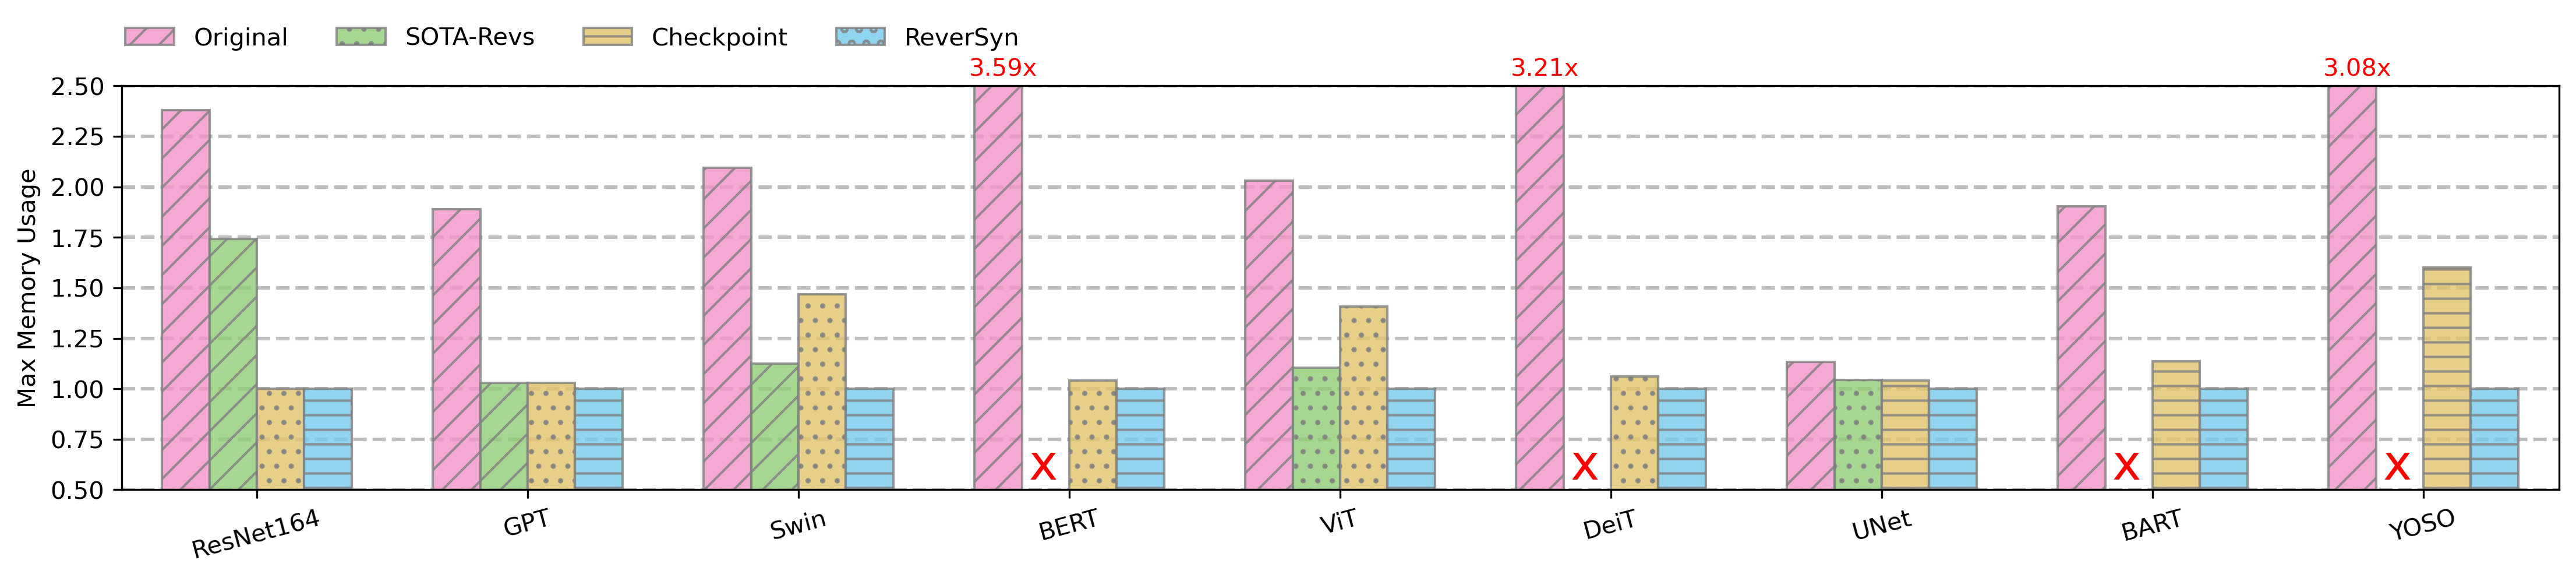

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF"]
sns.set_palette(colors)

hatches = ["//", "..", "--", "oo"]

plt.rcParams["figure.figsize"] = (18, 3)
ax = sns.barplot(memory, x="model", y="ratio", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=0.8, width=0.7)

plt.xlabel(None)
plt.ylabel("Max Memory Usage")
legend = plt.legend(loc="upper center", bbox_to_anchor=(0.185, 1.2), ncols=4, frameon=False)

for patch, hatch in zip(legend.get_patches(), hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("gray")

plt.xticks(rotation=15)
plt.ylim(0.5, 2.5)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(model_names)])
    bar.set_edgecolor("gray")
    
# manual
manual_indices = [12, 14, 16, 17]
for index in manual_indices:
    bar = ax.patches[index]
    plt.text(bar.get_x() + 0.025, 0.55, "x", color="red", fontsize=20)

# bert
bar = ax.patches[3]
plt.text(bar.get_x() - 0.02, 2.55, f'{memory[(memory.model == "BERT") & (memory.method == "Original")].ratio.item():.2f}x', color="red")

# diet
bar = ax.patches[5]
plt.text(bar.get_x() - 0.02, 2.55, f'{memory[(memory.model == "DeiT") & (memory.method == "Original")].ratio.item():.2f}x', color="red")

# bart
bar = ax.patches[8]
plt.text(bar.get_x() - 0.02, 2.55, f'{memory[(memory.model == "YOSO") & (memory.method == "Original")].ratio.item():.2f}x', color="red")

for y in [0.25 * i for i in range(2, 12)]:
    ax.axhline(y=y, color="gray", linestyle="--", zorder=0, alpha=0.5)

plt.savefig("memory2.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)